In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt
import random

import torch

import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


'NTC'

In [4]:
data = sc.read_h5ad(f"{paths.DATA_DIR}/raefish/raefish.h5ad")
slk.pp.slk_prepare_data(data, pert_key="RaeFishGene", ntc_label="NonTargeting", treatment_key=None, inplace=True)

AnnData object with n_obs × n_vars = 17931 × 492
    obs: 'dataset', 'fov', 'cell_id', 'cell_type_raw', 'total_merfish', 'total_raefish', 'top1_id', 'top2_id', 'top1_ratio', 'top2_ratio', 'top1_rae_count', 'top2_rae_count', 'RaeFishGene', 'treatment', 'pert'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'merfish_norm'

93 / 551 perturbations (16.9%) occur in exactly one dataset


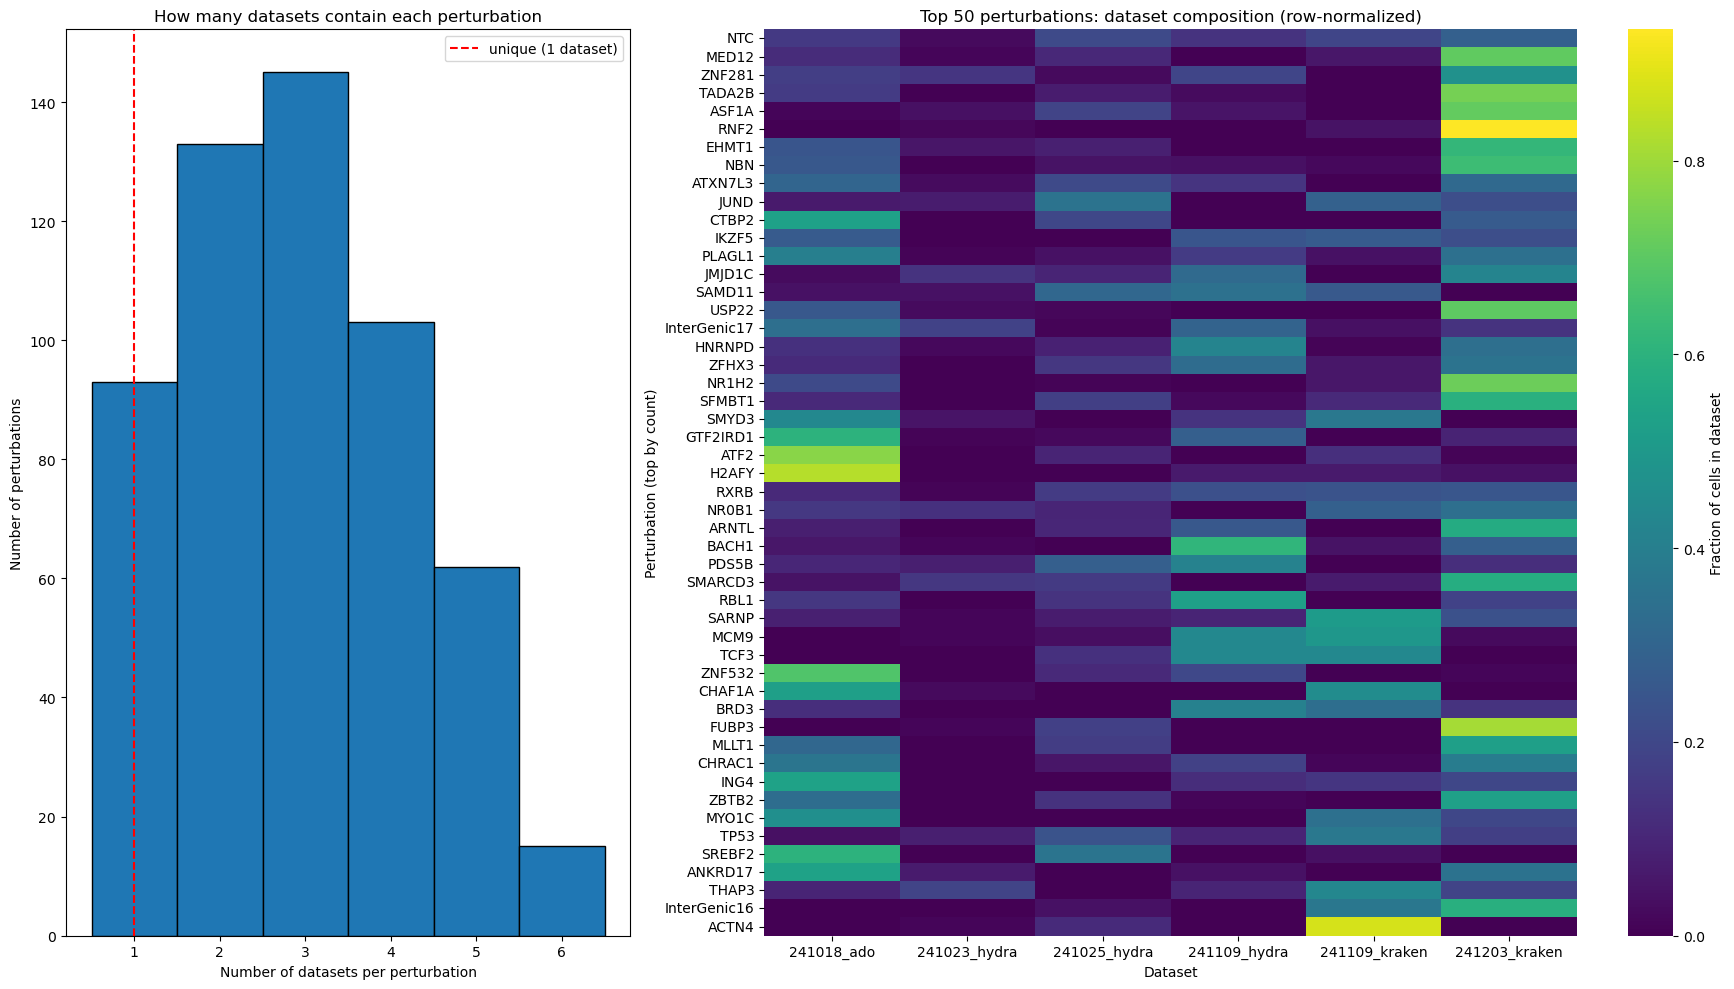

In [5]:
# plot distribution of perturbations across datasets to check dataset-uniqueness
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])  # perturbation x dataset counts
datasets_per_pert = (ct > 0).sum(axis=1)

# summary
n_total = len(datasets_per_pert)
n_unique = (datasets_per_pert == 1).sum()
print(f"{n_unique} / {n_total} perturbations ({n_unique/n_total:.1%}) occur in exactly one dataset")

# figure: histogram of how many datasets each perturbation appears in + heatmap of top perturbations
topN = 50
top_pert = ct.sum(axis=1).sort_values(ascending=False).head(topN).index
ct_top = ct.loc[top_pert]
ct_top_frac = ct_top.divide(ct_top.sum(axis=1), axis=0).fillna(0)  # row-normalized fractions

fig, axes = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [1, 1.8]})

# histogram
axes[0].hist(datasets_per_pert, bins=range(1, datasets_per_pert.max() + 2), color='C0', edgecolor='k', align='left')
axes[0].set_xlabel('Number of datasets per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].axvline(1, color='red', linestyle='--', label='unique (1 dataset)')
axes[0].legend()
axes[0].set_title('How many datasets contain each perturbation')

# heatmap for top perturbations (row-normalized)
sns.heatmap(ct_top_frac, ax=axes[1], cmap='viridis', cbar_kws={'label': 'Fraction of cells in dataset'},
            yticklabels=True)
axes[1].set_ylabel('Perturbation (top by count)')
axes[1].set_xlabel('Dataset')
axes[1].set_title(f'Top {topN} perturbations: dataset composition (row-normalized)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_772452/966415500.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])


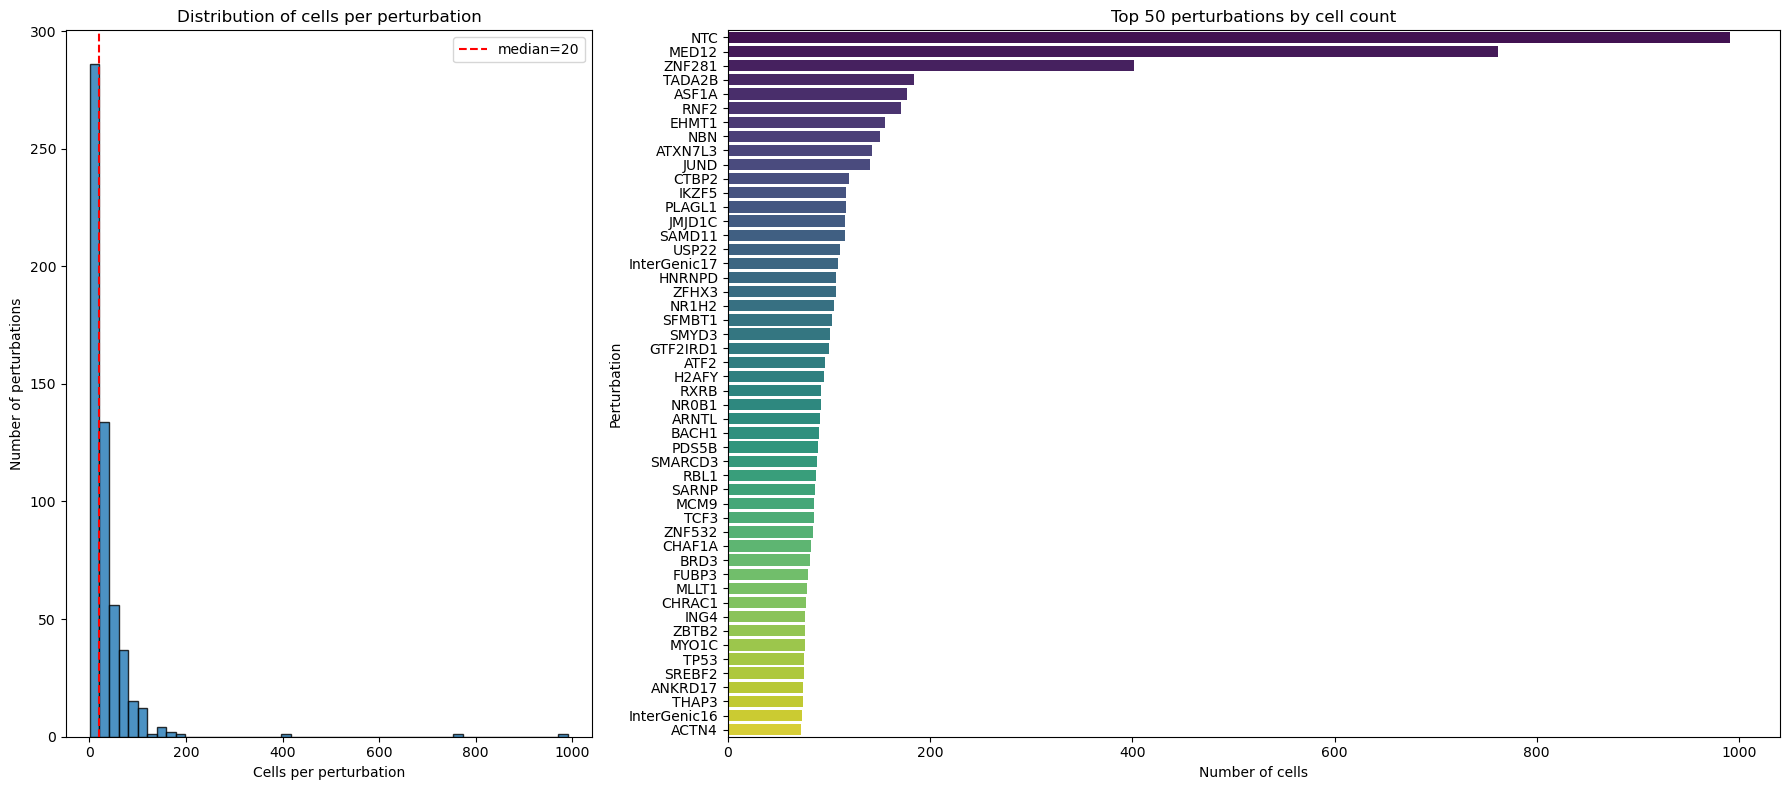

In [6]:
# plot number of cells per perturbation: histogram + top N barplot
pert_counts = ct.sum(axis=1)  # ct is perturbation x dataset counts

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 2]})

# histogram of counts
axes[0].hist(pert_counts.values, bins=50, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Cells per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Distribution of cells per perturbation')
axes[0].axvline(pert_counts.median(), color='red', linestyle='--', label=f'median={int(pert_counts.median())}')
axes[0].legend()

# horizontal barplot of top N perturbations
topN = min(50, len(pert_counts))
top = pert_counts.sort_values(ascending=False).head(topN)
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Number of cells')
axes[1].set_ylabel('Perturbation')
axes[1].set_title(f'Top {topN} perturbations by cell count')

plt.tight_layout()
plt.show()

In [7]:
# Cross-tab of counts: rows=perturbations, cols=datasets
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])

# Number of perturbations unique to the dataset
datasets_per_pert = (ct > 0).sum(axis=1)              # in how many datasets each pert appears
unique_perts = datasets_per_pert[datasets_per_pert == 1].index
unique_perts_per_dataset = (ct.loc[unique_perts] > 0).sum(axis=0).reindex(ct.columns, fill_value=0)

# Number of total perturbations in the dataset
total_perts_per_dataset = (ct > 0).sum(axis=0).astype(int)

# Number of cells in the dataset
cells_per_dataset = ct.sum(axis=0).astype(int)

# Average number of cells per perturbation in the dataset
avg_cells_per_pert = (cells_per_dataset / total_perts_per_dataset.replace(0, np.nan)).fillna(0).round(2)

# Assemble a single summary table
summary = pd.DataFrame({
    "unique_perturbations": unique_perts_per_dataset.astype(int),
    "total_perturbations": total_perts_per_dataset.astype(int),
    "cells": cells_per_dataset.astype(int),
    "avg_cells_per_perturbation": avg_cells_per_pert
}).reindex(ct.columns)

print("Per-dataset summary:")
print(summary)


Per-dataset summary:
               unique_perturbations  total_perturbations  cells  \
dataset                                                           
241018_ado                       22                  339   3924   
241023_hydra                      9                  201    961   
241025_hydra                     15                  316   2533   
241109_hydra                     17                  240   2704   
241109_kraken                     9                  203   2467   
241203_kraken                    21                  307   5342   

               avg_cells_per_perturbation  
dataset                                    
241018_ado                          11.58  
241023_hydra                         4.78  
241025_hydra                         8.02  
241109_hydra                        11.27  
241109_kraken                       12.15  
241203_kraken                       17.40  


In [8]:
data = data[data.obs.dataset == '241203_kraken']

/tmp/ipykernel_772452/340320454.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])


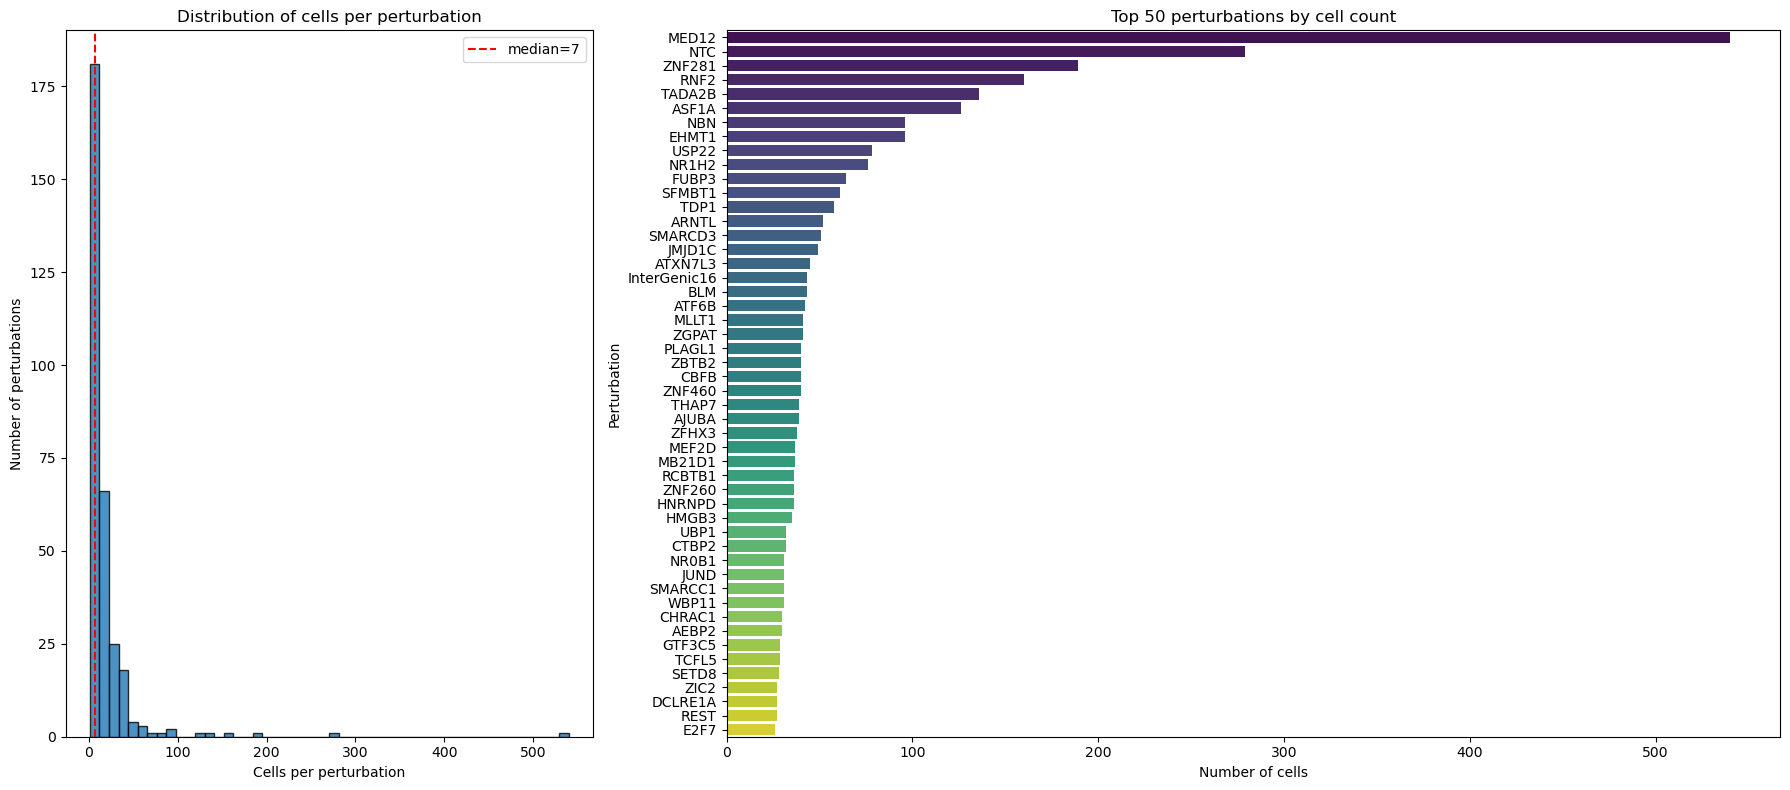

In [9]:
# plot number of cells per perturbation: histogram + top N barplot
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])
pert_counts = ct.sum(axis=1)  # ct is perturbation x dataset counts

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 2]})

# histogram of counts
axes[0].hist(pert_counts.values, bins=50, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Cells per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Distribution of cells per perturbation')
axes[0].axvline(pert_counts.median(), color='red', linestyle='--', label=f'median={int(pert_counts.median())}')
axes[0].legend()

# horizontal barplot of top N perturbations
topN = min(50, len(pert_counts))
top = pert_counts.sort_values(ascending=False).head(topN)
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Number of cells')
axes[1].set_ylabel('Perturbation')
axes[1].set_title(f'Top {topN} perturbations by cell count')

plt.tight_layout()
plt.show()

In [10]:
min_cells = 20

# Global counts per perturbation (across all datasets)
pert_counts_full = data.obs['pert'].value_counts()

# Keep perturbations with >= min_cells total cells (ignore per-dataset splits)
valid_perts = pert_counts_full[pert_counts_full >= min_cells].index

mask = data.obs['pert'].isin(valid_perts)
print(f"Keeping {mask.sum()} / {data.n_obs} cells ({mask.sum()/data.n_obs:.1%}) "
      f"from {len(valid_perts)} perturbations (>= {min_cells} cells total)")

# Subset
data = data[mask].copy()

# Recompute summaries
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])
pert_counts = ct.sum(axis=1).astype(int)
datasets_per_pert = (ct > 0).sum(axis=1).astype(int)


Keeping 3898 / 5342 cells (73.0%) from 77 perturbations (>= 20 cells total)


/tmp/ipykernel_772452/340320454.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])


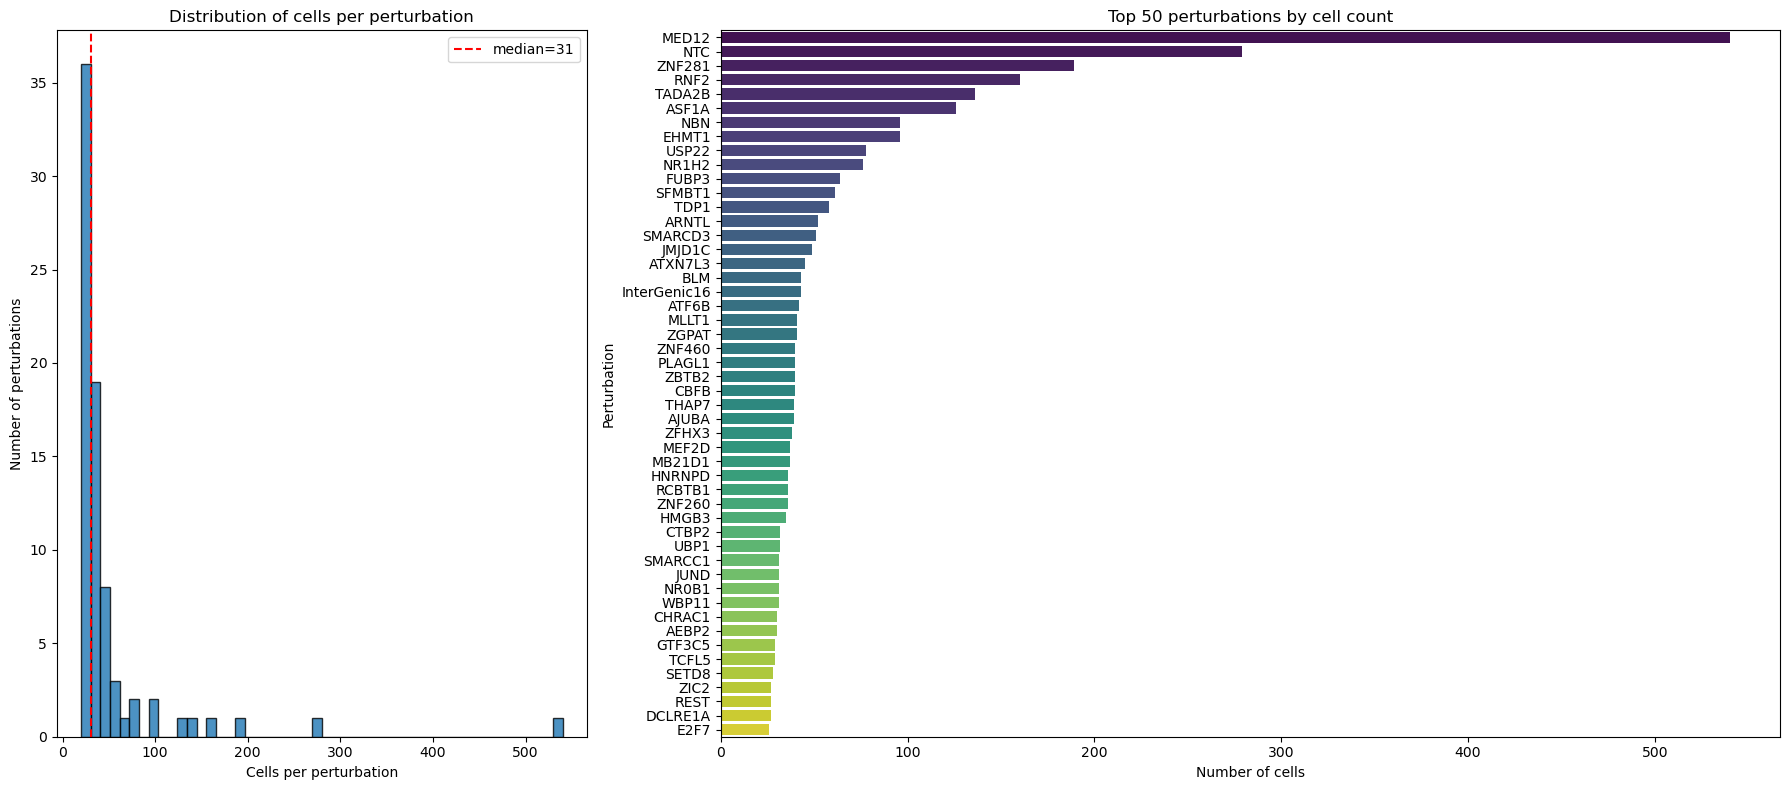

In [11]:
# plot number of cells per perturbation: histogram + top N barplot
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])
pert_counts = ct.sum(axis=1)  # ct is perturbation x dataset counts

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 2]})

# histogram of counts
axes[0].hist(pert_counts.values, bins=50, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Cells per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Distribution of cells per perturbation')
axes[0].axvline(pert_counts.median(), color='red', linestyle='--', label=f'median={int(pert_counts.median())}')
axes[0].legend()

# horizontal barplot of top N perturbations
topN = min(50, len(pert_counts))
top = pert_counts.sort_values(ascending=False).head(topN)
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Number of cells')
axes[1].set_ylabel('Perturbation')
axes[1].set_title(f'Top {topN} perturbations by cell count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_772452/1378270000.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_772452/1378270000.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


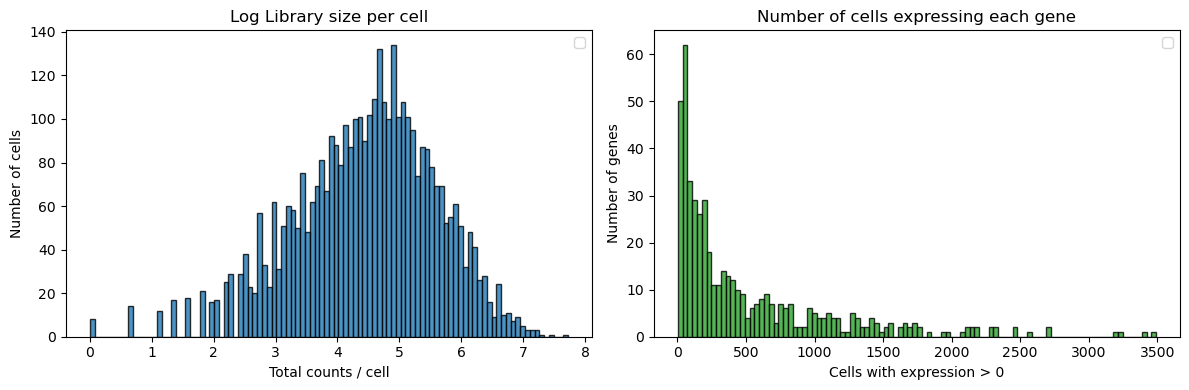

In [12]:
import scipy.sparse as sps

# fallback: sum across expression matrix
lib_size = np.asarray(data.X.sum(axis=1)).ravel()

# 2) number of cells per gene (non-zero counts)
X = data.X
if sps.issparse(X):
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    cells_per_gene = (X > 0).sum(axis=0).astype(int)

# 3) Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Library size histogram
axes[0].hist(np.log(lib_size+1), bins=100, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_title('Log Library size per cell')
axes[0].set_xlabel('Total counts / cell')
axes[0].set_ylabel('Number of cells')
axes[0].legend()

# Cells per gene histogram
axes[1].hist(cells_per_gene, bins=100, color='C2', edgecolor='k', alpha=0.8)
axes[1].set_title('Number of cells expressing each gene')
axes[1].set_xlabel('Cells with expression > 0')
axes[1].set_ylabel('Number of genes')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# filter cells by log1p(lib_size) > 3 and subset to highly variable genes
cell_mask = np.log(lib_size + 1) > 3
print(f"Keeping {cell_mask.sum()} / {data.n_obs} cells (log1p(lib_size) > 3)")

data = data[cell_mask].copy()

Keeping 3436 / 3898 cells (log1p(lib_size) > 3)


In [14]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 76/76 [00:00<00:00, 2156.09it/s]


In [15]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = slk.tl.run_single(data, 
#                             batch_size=4096,
#                              shuffle=True, 
#                              num_workers=0, 
#                              device=device, 
#                              ce_lambda=1e-3, 
#                              num_epochs=1000,
#                              l0_lambda=10,
#                              latent_dim=16,
#                              patience=1000,
#                              ntc_lambda=1e-7,
#                              pert_lambda=1e8,
#                              rank=6,
#                              gate_init_p=0.5,
#                              tau_init=0.5,
#                              tau_end=0.1,
#                              shift='linear'
#                              )

In [16]:
#slk.tl.save_results(results, f'{paths.RESULTS_DIR}/models/raefish.pth')

In [17]:
# model = slk.tl.load_results(f'{paths.RESULTS_DIR}/models/raefish.pth')

In [18]:
# NUM_EPOCHS     = 2000
# VALIDATE_EVERY = 50
# BATCH_SIZE     = 4096
# LATENT_DIM     = 20
# PATIENCE       = 350
# SHERLOCK_KWARGS = {
#     # "tau_end": 0.3,
#     # # "tau_init": 1.5,
#     # "cov_lambda": 1e-5,
#     # "H_lambda": 1e-1,
#     # "gate_row_repulsion_lambda": 1e-2,
#     # "ce_lambda": 10,
#     # "shift": "linear",
#     "l0_lambda":35,
#     "debug": True,
#     # "lr": 1e-3,
#     # "ntc_lambda": 1e-5,       
#     # "pert_lambda": 1,
#     "n_epochs_l0_warmup": 400
# }


# seed = 3
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = slk.tl.run(
#         data,
#         model="vae",
#         batch_size=BATCH_SIZE,
#         num_epochs=NUM_EPOCHS,
#         device=DEVICE,
#         latent_dim=LATENT_DIM,
#         patience=PATIENCE,
#         validate_every=VALIDATE_EVERY,
#         seed=seed,
#         # debug=True,
#         **SHERLOCK_KWARGS,
#     )

In [19]:
# import datetime
    
# timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# slk.tl.save_results(results, f'{paths.RESULTS_DIR}/models/raefish_model_{timestamp}_{seed}.pth')

# print(f'Saved results to ../data/raefish_model_{timestamp}_{seed}.pth')

In [20]:
# Saved results to ../data/raefish_model_20260531_202810_1.pth
# Saved results to ../data/raefish_model_20260601_001517_0.pth 
# Saved results to ../data/raefish_model_20260603_110011_2.pth
# Saved results to ../data/raefish_model_20260603_111544_2.pth

In [22]:
model = slk.tl.load_results(f'{paths.RESULTS_DIR}/models/raefish_model_20260603_112214_3.pth')

In [23]:
# model = results['model']

In [24]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [25]:
data.uns['results']

{'z_corr': array([[ 1.        ,  0.29871112,  0.2714467 , ..., -0.03481417,
         -0.35244972, -0.341107  ],
        [ 0.29871112,  1.        ,  0.23555253, ...,  0.584269  ,
          0.398321  , -0.03406876],
        [ 0.27144668,  0.23555253,  1.        , ...,  0.08707917,
         -0.01650721,  0.24739866],
        ...,
        [-0.03481417,  0.584269  ,  0.08707917, ...,  1.        ,
          0.3357089 , -0.0640385 ],
        [-0.35244974,  0.398321  , -0.01650721, ...,  0.3357089 ,
          1.        ,  0.5263359 ],
        [-0.341107  , -0.03406876,  0.24739866, ..., -0.0640385 ,
          0.5263359 ,  1.        ]], dtype=float32),
 'z_perts': array(['AEBP2', 'AJUBA', 'ANKRD17', 'ARNTL', 'ASF1A', 'ATF6B', 'ATXN7L3',
        'BACH1', 'BLM', 'CBFB', 'CHRAC1', 'CRAMP1L', 'CTBP2', 'DCLRE1A',
        'E2F7', 'EHMT1', 'FOSL2', 'FUBP3', 'GTF3C5', 'HDAC4', 'HMGB3',
        'HMGN4', 'HNRNPD', 'IKZF5', 'InterGenic16', 'JMJD1C', 'JUND',
        'KLF3', 'MAFK', 'MAPK1', 'MB21D1', 'MED1

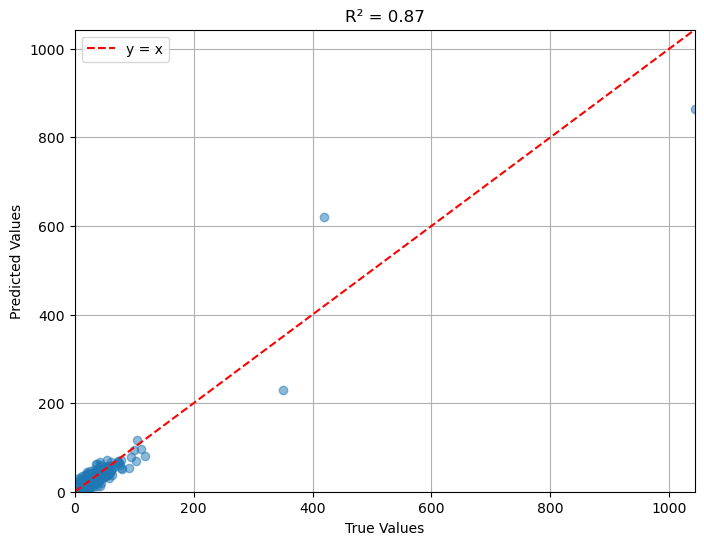

In [26]:
slk.pl.plot_r2(data)

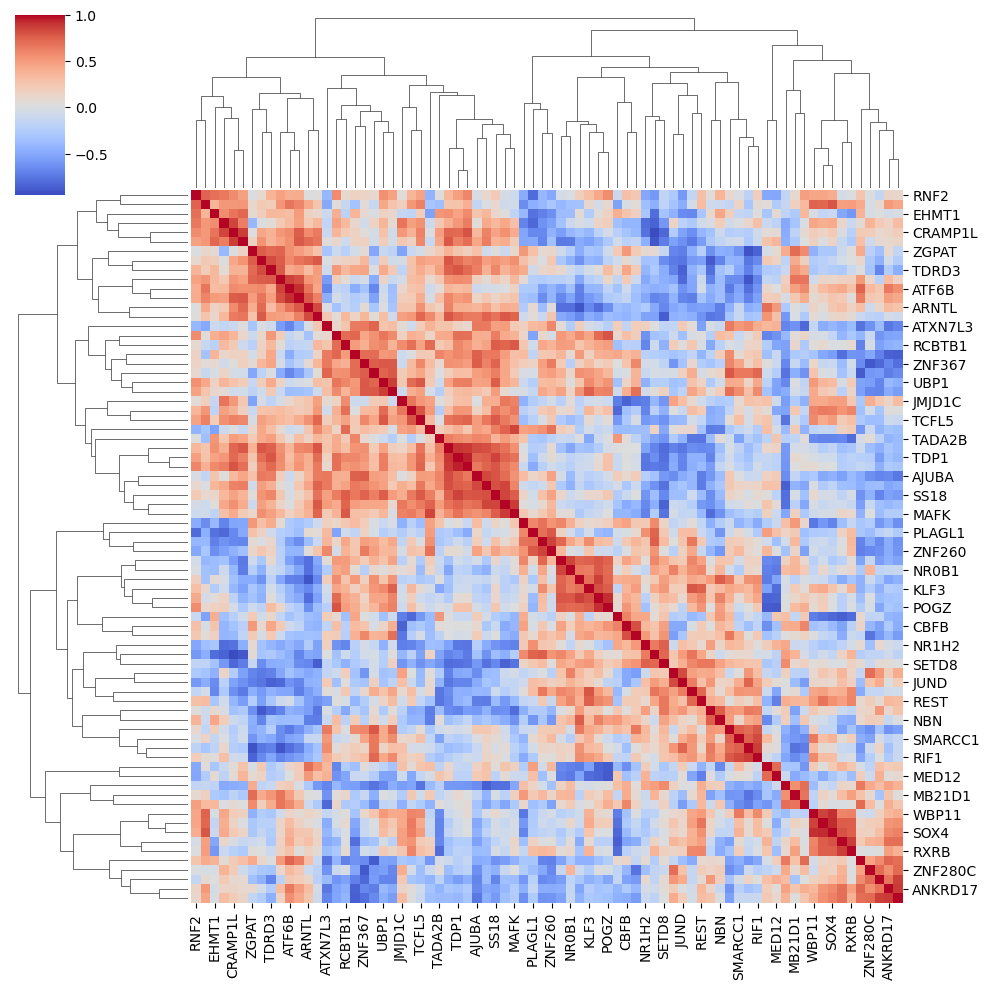

In [27]:
slk.pl.plot_corr(data)

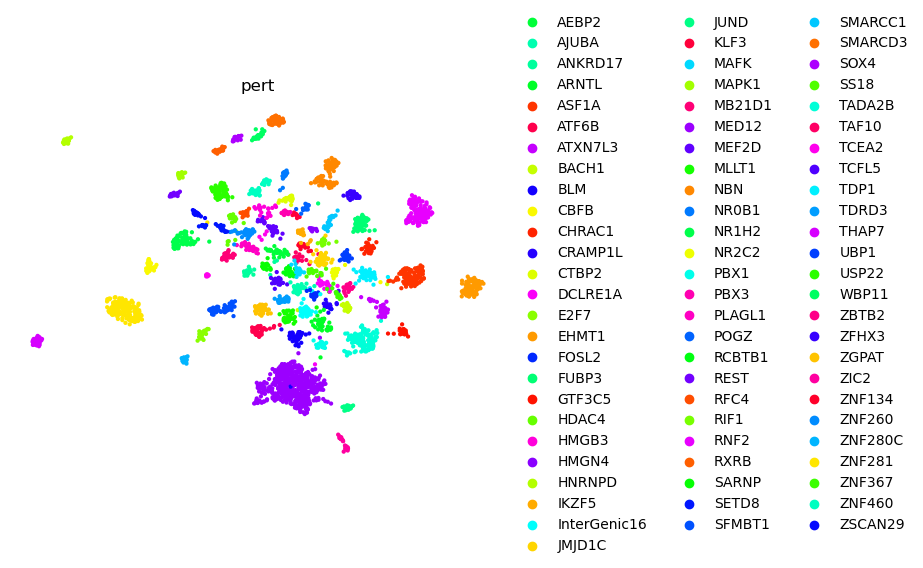

In [28]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)


n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [29]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12, 'svg.fonttype': 'none','figure.figsize': (3, 2) }) # Set default figure size to 6×4 inches})
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
figure_dir = f"{paths.FIGURES_DIR}/raefish/"
os.makedirs(figure_dir, exist_ok=True)
pert_type = "spatial"

/tmp/ipykernel_772452/3891022321.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


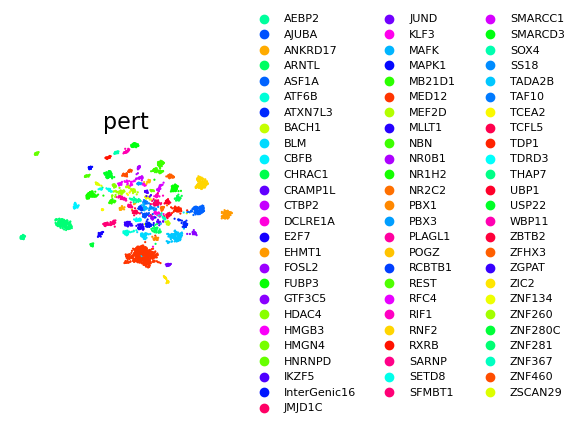

In [30]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.seed(42)  # for reproducibility
random.shuffle(palette)
plt.rcParams.update({'font.size': 8}) 
sc.pl.umap(sub, color='pert', palette=palette, frameon=False, show=False, s=10)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace_labeled.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace_labeled.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace_labeled.pdf"), dpi=300, bbox_inches='tight')
plt.show()
plt.rcParams.update({'font.size': 12}) 

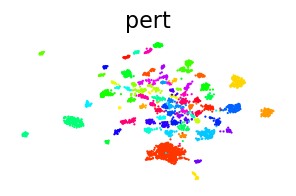

In [31]:
plt.rcParams.update({'font.size': 8}) 
sc.pl.umap(sub, color='pert', palette=palette, frameon=False, show=False,legend_loc='none', s=10)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace.pdf"), dpi=300, bbox_inches='tight')
plt.show()
plt.rcParams.update({'font.size': 12}) 

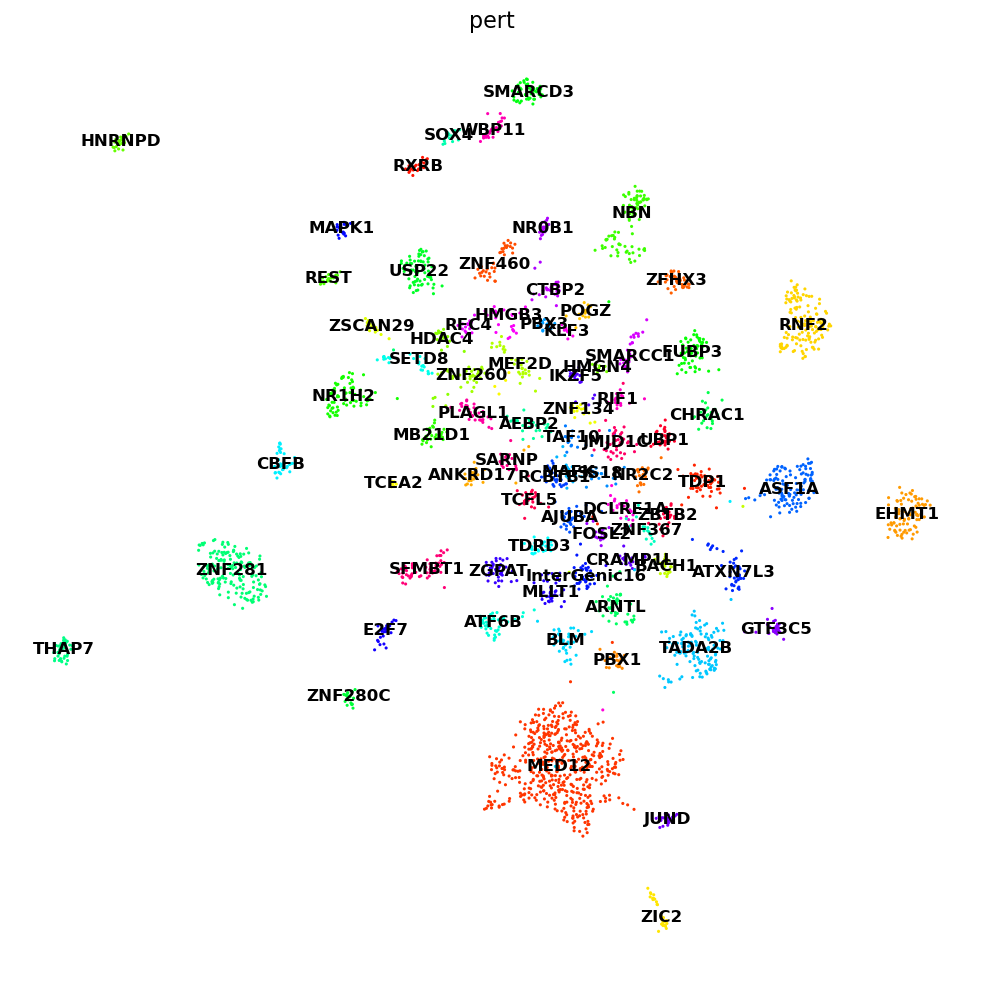

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))
sc.pl.umap(sub, color='pert', palette=palette, frameon=False, legend_loc='on data', s=20, ax=ax, show=False)
plt.tight_layout()

In [33]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.804  (p = 0.0e+00)
 Pearson  r = 0.812  (p = 0.0e+00)


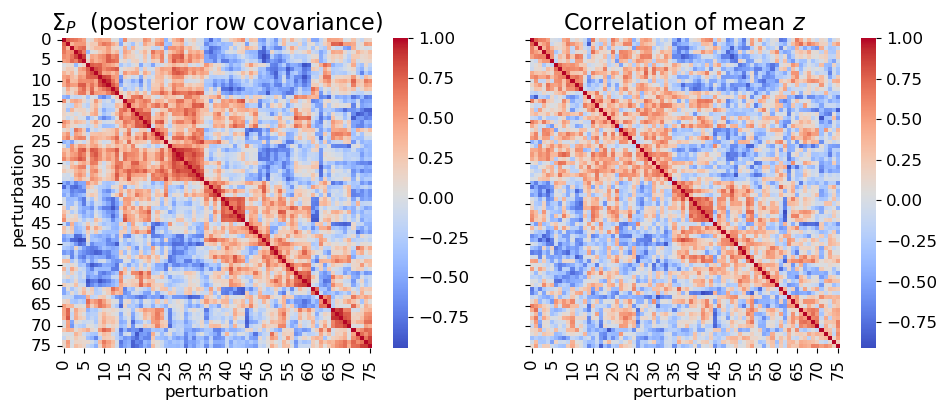

In [34]:
slk.pl.plot_zcorr(data)

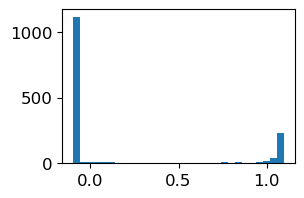

In [35]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

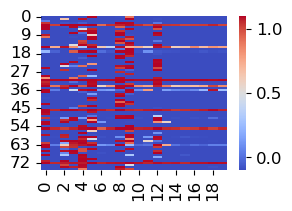

In [36]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [37]:

dataset = slk.tl.PerturbMatchingDataset(data)
all_genes = dataset.perturbation_dict.keys()

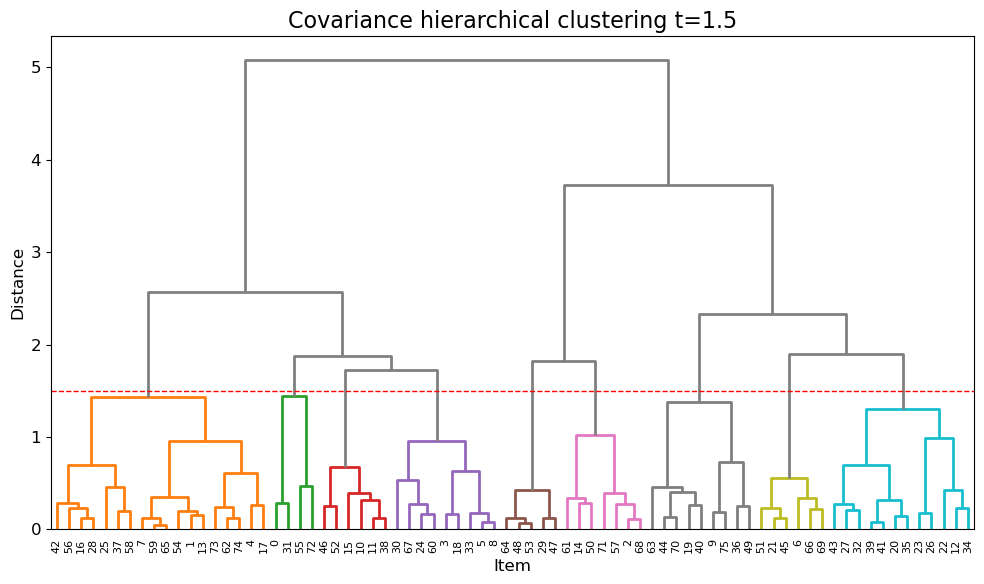

In [38]:
groups = slk.tl.cluster_rho(data, t=1.5, show=True)

In [39]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
AEBP2,2
AJUBA,1
ANKRD17,6
ARNTL,4
ASF1A,1
...,...
ZNF280C,6
ZNF281,2
ZNF367,1
ZNF460,1


pert_group
1    616
2    827
3    332
4    324
5    108
6    204
7    321
8    146
9    315
Name: count, dtype: int64


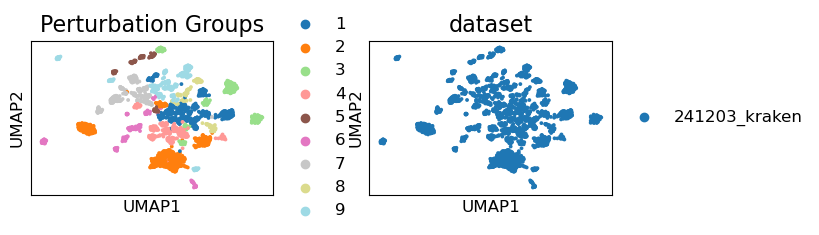

In [40]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group', 'dataset'], title='Perturbation Groups', palette='tab20', size=30)

In [41]:
new_colormap = [
'darkslateblue', # 0
'firebrick', # 1
'darkorange', # 2
'forestgreen', # 3
'gold', # 4
'dodgerblue', # 5
'mediumorchid', # 6
'deeppink', # 7
'teal', # 8
'black' # 9
]

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from matplotlib.colors import to_hex

def cluster_rho(adata, t=1.5, uns_key='results', rho_corr=None, show=True, pert_key=None, figure_dir=None, save_name=None):
    if rho_corr is None:
        C = adata.uns[uns_key]['rho_corr']
    else:
        C = rho_corr
    
    # Get perturbation names - try multiple possible locations
    if 'pert_names' in adata.uns.get(uns_key, {}):
        pert_names = adata.uns[uns_key]['pert_names']
    elif 'rho_perts' in adata.uns.get(uns_key, {}):
        pert_names = list(adata.uns[uns_key]['rho_perts'])
    elif 'perts' in adata.uns.get(uns_key, {}):
        pert_names = adata.uns[uns_key]['perts']
    else:
        # Fall back to unique values from obs
        _pk = pert_key or slk.configs.get_config('pert_key')
        pert_names = adata.obs[_pk].cat.categories.tolist()
        # Remove control if present
        pert_names = [p for p in pert_names if p.lower() not in ['control', 'ctrl', 'non-targeting']]
    
    D = 1.0 - C  # distance
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    
    # Get cluster groups first for coloring
    groups = fcluster(Z_link, t=t, criterion='distance')
    
    if show:
        # Create cluster to color mapping
        unique_groups = sorted(set(groups))
        
        # Set default colors for dendrogram using new_colormap
        palette_hex = [to_hex(c) if isinstance(c, tuple) else c for c in new_colormap[:len(unique_groups)]]
        set_link_color_palette(palette_hex)
        
        plt.figure(figsize=(max(5, len(pert_names) * 0.11), 3.5))
        dendrogram(
            Z_link,
            color_threshold=t,
            above_threshold_color="gray",
            labels=pert_names,  # Use actual names
            leaf_rotation=90,
            leaf_font_size=8,
        )
        plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
        #plt.title(f"Covariance hierarchical clustering t={t}")
        plt.xlabel("Perturbation")
        plt.ylabel("Distance")
        plt.tight_layout()
        
        # Export the figures
        if figure_dir and save_name:
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.svg"), dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.png"), dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.pdf"), dpi=300, bbox_inches='tight')
            print(f"Saved figures to {figure_dir}/{save_name}_dendrogram.[svg|png|pdf]")
        
        plt.show()
    
    # Return as a dictionary mapping perturbation names to cluster IDs
    cluster_assignments = dict(zip(pert_names, groups))
    
    return groups, cluster_assignments

Saved figures to /home/user/Documents/Githubs/PerturbVAE/sherlock/results/figures//spatial__dendrogram.[svg|png|pdf]


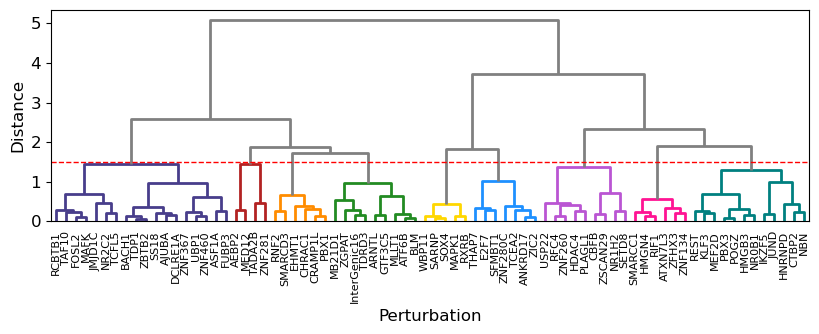

In [43]:
groups = cluster_rho(data, t=1.5, show=True, figure_dir=figure_dir, save_name=f"{pert_type}_")

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

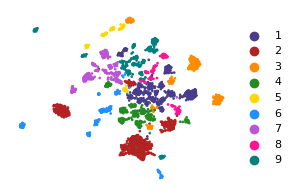

In [44]:

import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (3, 2)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

sc.pl.umap(sub, color=['pert_group'], title='', palette=new_colormap, size=15, frameon=False, show=False)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace_conditions_group.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace_conditions_group.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_sherlock_zspace_conditions_group.pdf"), dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_772452/2970488846.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pert_to_group = adata.obs.groupby(p_key)[group_col].first().to_dict()
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not fou

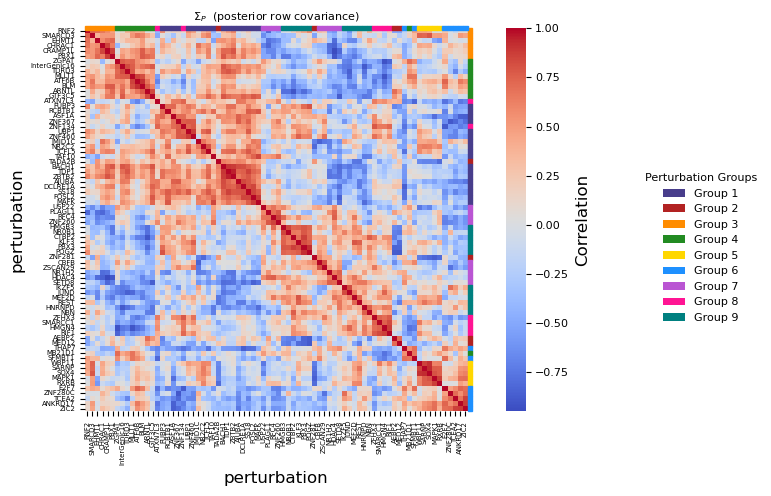

In [45]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib import gridspec
from matplotlib.patches import Patch


def plot_zcorr_colored(adata, uns_key='results', show_pert_labels=True, group_col='pert_group', group_color = new_colormap):
    """
    Plot correlation matrices with color bars for each perturbation group.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object with results in adata.uns[uns_key].
    uns_key : str, default 'results'
        Key in adata.uns where results are stored.
    show_pert_labels : bool, default True
        Whether to show perturbation labels on axes.
    group_col : str, default 'pert_group'
        Column in adata.obs containing perturbation groups.
    """
    
    Sigma_P_posterior = adata.uns[uns_key]['rho_corr']
    Sigma_z = adata.uns[uns_key]['z_corr']
    pert_names = adata.uns[uns_key].get('rho_perts', adata.uns[uns_key].get('perts'))

    link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
    order = leaves_list(link)              # permutation indices, shape (P,)

    # Apply the same permutation to both matrices
    SigmaP_ord = Sigma_P_posterior[order][:, order]
    Sigmaz_ord = Sigma_z[order][:, order]
    
    # Reorder perturbation names
    pert_names_ord = pert_names[order]
    
    # Get perturbation groups
    p_key = slk.configs.get_config('pert_key')
    pert_to_group = adata.obs.groupby(p_key)[group_col].first().to_dict()
    
    # Map perturbations to groups and create colors
    pert_groups = [pert_to_group.get(name, -1) for name in pert_names_ord]
    unique_groups = sorted(set(pert_groups))
    n_groups = len(unique_groups)
    
    # Create color palette for groups (not individual perturbations)
    group_colors = sns.color_palette(group_color, n_groups)
    group_to_color = {grp: group_colors[i] for i, grp in enumerate(unique_groups)}
    row_colors = [group_to_color[grp] for grp in pert_groups]
    
    n_perts = len(pert_names_ord)

    # Thickness controls for color bars
    top_bar_height = 0.8   # was 0.5
    side_bar_width = 0.8   # was 0.5

    # Plot single heatmap
    fig = plt.figure(figsize=(8, 5))
    ax0 = fig.add_subplot(111)
    
    sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=ax0, 
                xticklabels=pert_names_ord if show_pert_labels else False,
                yticklabels=pert_names_ord if show_pert_labels else False,
                cbar_kws={'label': 'Correlation'})
    ax0.set_title(r"$\Sigma_P$  (posterior row covariance)")
    ax0.set_xlabel("perturbation")
    ax0.set_ylabel("perturbation")
    
    # Make font size smaller
    if show_pert_labels:
        ax0.set_xticklabels(ax0.get_xticklabels(), fontsize=5)
        ax0.set_yticklabels(ax0.get_yticklabels(), fontsize=5)
    
    # Add color bar on top and right (thicker)
    for i, color in enumerate(row_colors):
        # Top
        ax0.add_patch(plt.Rectangle((i, -0.5), 1, top_bar_height, color=color, 
                                    transform=ax0.transData, clip_on=False))
        # Right
        ax0.add_patch(plt.Rectangle((n_perts, i), side_bar_width, 1, color=color, 
                                    transform=ax0.transData, clip_on=False))

    # Create legend outside with transparent background
    legend_elements = [Patch(facecolor=group_to_color[grp], label=f'Group {grp}') 
                      for grp in unique_groups]
    fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        title='Perturbation Groups',
        fontsize=8,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_correlation_color.svg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_correlation_color.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_correlation_color.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

plot_zcorr_colored(sub)

In [46]:
for i in sub.obs.pert_group.unique():
    print(i)
    print(sub[sub.obs.pert_group == i].obs['pert'].value_counts())

1
pert
ASF1A      114
FUBP3       60
TDP1        53
JMJD1C      39
ZNF460      37
AJUBA       35
RCBTB1      30
UBP1        30
TCFL5       28
ZBTB2       26
BACH1       25
DCLRE1A     24
NR2C2       22
FOSL2       21
TAF10       19
MAFK        18
SS18        18
ZNF367      17
Name: count, dtype: int64
2
pert
MED12     509
ZNF281    163
TADA2B    126
AEBP2      29
Name: count, dtype: int64
4
pert
ARNTL           46
BLM             42
ATF6B           41
ZGPAT           39
InterGenic16    37
MLLT1           36
MB21D1          31
GTF3C5          28
TDRD3           24
Name: count, dtype: int64
3
pert
RNF2       134
EHMT1       86
SMARCD3     46
CHRAC1      26
PBX1        21
CRAMP1L     19
Name: count, dtype: int64
9
pert
NBN       86
MEF2D     31
CTBP2     25
HNRNPD    25
JUND      24
HMGB3     24
IKZF5     20
NR0B1     20
REST      19
POGZ      17
PBX3      15
KLF3       9
Name: count, dtype: int64
8
pert
ATXN7L3    40
ZFHX3      36
SMARCC1    29
ZNF134     16
RIF1       15
HMGN4      10
N

In [47]:
# Print gene symbols per group, one gene per line (no quotation marks)
grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())

for grp in sorted(grouped.index):
    print(f"Group {grp}:")
    for gene in grouped.loc[grp]:
        print(gene)
    print()

Group 1:
AJUBA
ASF1A
BACH1
DCLRE1A
FOSL2
FUBP3
JMJD1C
MAFK
NR2C2
RCBTB1
SS18
TAF10
TCFL5
TDP1
UBP1
ZBTB2
ZNF367
ZNF460

Group 2:
AEBP2
MED12
TADA2B
ZNF281

Group 3:
CHRAC1
CRAMP1L
EHMT1
PBX1
RNF2
SMARCD3

Group 4:
ARNTL
ATF6B
BLM
GTF3C5
InterGenic16
MB21D1
MLLT1
TDRD3
ZGPAT

Group 5:
MAPK1
RXRB
SARNP
SOX4
WBP11

Group 6:
ANKRD17
E2F7
SFMBT1
TCEA2
THAP7
ZIC2
ZNF280C

Group 7:
CBFB
HDAC4
NR1H2
PLAGL1
RFC4
SETD8
USP22
ZNF260
ZSCAN29

Group 8:
ATXN7L3
HMGN4
RIF1
SMARCC1
ZFHX3
ZNF134

Group 9:
CTBP2
HMGB3
HNRNPD
IKZF5
JUND
KLF3
MEF2D
NBN
NR0B1
PBX3
POGZ
REST



/tmp/ipykernel_772452/2222304912.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())


In [48]:
grouped

group
1    [AJUBA, ASF1A, BACH1, DCLRE1A, FOSL2, FUBP3, J...
2                       [AEBP2, MED12, TADA2B, ZNF281]
3        [CHRAC1, CRAMP1L, EHMT1, PBX1, RNF2, SMARCD3]
4    [ARNTL, ATF6B, BLM, GTF3C5, InterGenic16, MB21...
5                    [MAPK1, RXRB, SARNP, SOX4, WBP11]
6    [ANKRD17, E2F7, SFMBT1, TCEA2, THAP7, ZIC2, ZN...
7    [CBFB, HDAC4, NR1H2, PLAGL1, RFC4, SETD8, USP2...
8       [ATXN7L3, HMGN4, RIF1, SMARCC1, ZFHX3, ZNF134]
9    [CTBP2, HMGB3, HNRNPD, IKZF5, JUND, KLF3, MEF2...
dtype: object

Group 1 (18 genes): 39 significant GO terms
Group 2 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 2 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 2: no results
Group 3 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 3 (6 genes): 8 significant GO terms
Group 4 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 4 (9 genes): 6 significant GO terms
Group 5 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 5 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 5: no results
Group 6 (7 genes): 49 significant GO terms
Group 7 (9 genes): 105 significant GO terms
Group 8 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 8 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 8: no results


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Group 9 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 9 (12 genes): 97 significant GO terms


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

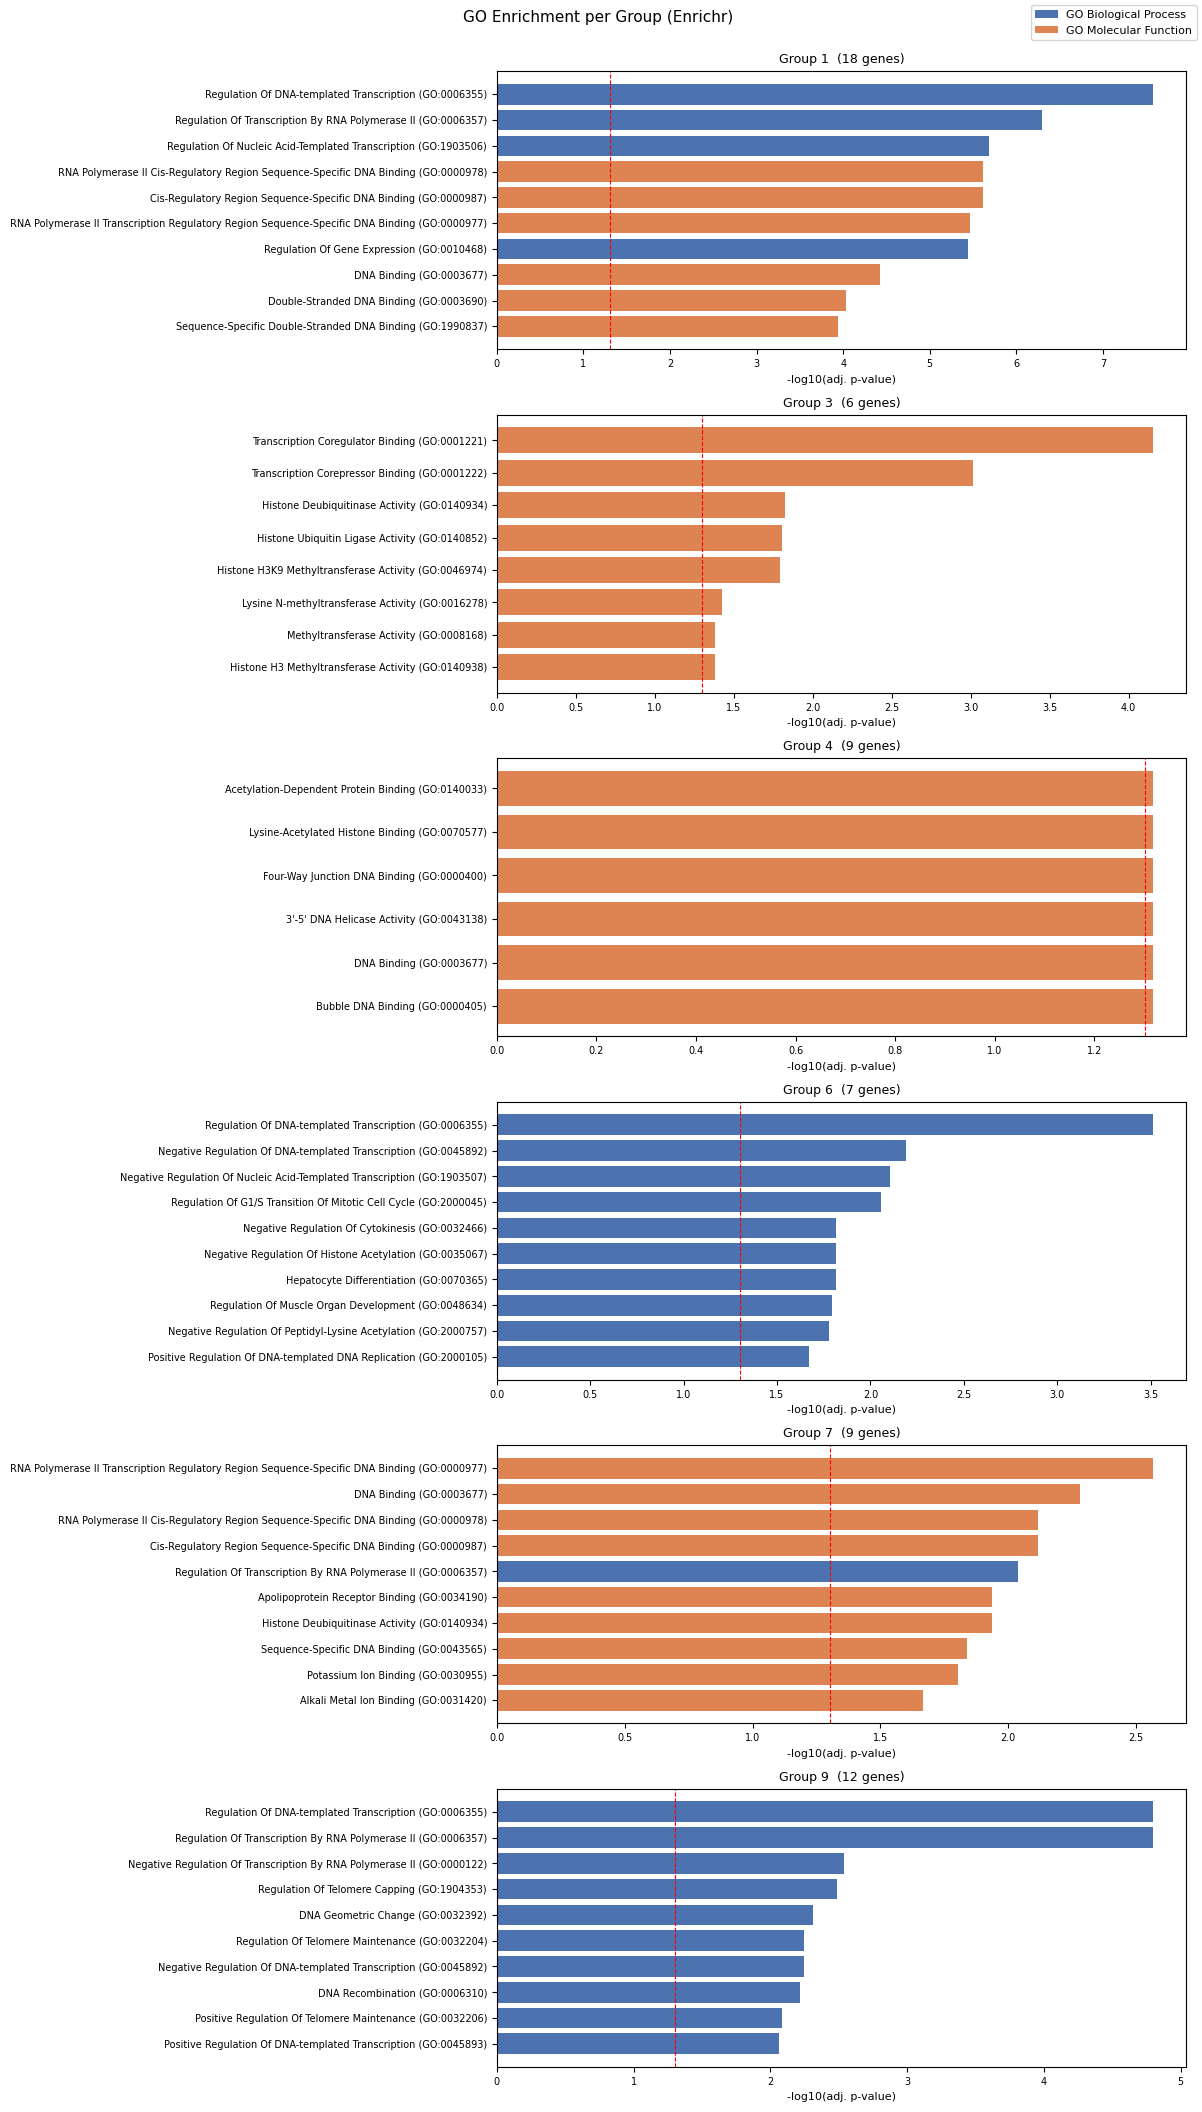

Saved full GO results to /home/user/Documents/Githubs/PerturbVAE/sherlock/results/figures//go_enrichment_per_group.csv


In [49]:
# GO enrichment analysis per group using gseapy Enrichr
import gseapy as gp
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GO_LIBS     = ["GO_Biological_Process_2023", "GO_Molecular_Function_2023"]
PVAL_CUTOFF = 0.05
TOP_N       = 10

all_results = {}

for grp in sorted(grouped.index):
    genes = [g for g in grouped.loc[grp] if isinstance(g, str)]
    if len(genes) < 3:
        print(f"Group {grp}: too few genes ({len(genes)}), skipping.")
        continue
    group_dfs = []
    for lib in GO_LIBS:
        try:
            enr = gp.enrichr(gene_list=genes, gene_sets=lib, organism="human",
                             outdir=None, verbose=False)
            df = enr.results.copy()
            df["library"] = lib
            group_dfs.append(df)
        except Exception as e:
            print(f"Group {grp} / {lib}: {e}")
    if group_dfs:
        combined = pd.concat(group_dfs, ignore_index=True)
        combined = combined[combined["Adjusted P-value"] < PVAL_CUTOFF].copy()
        combined["-log10(adjP)"] = -combined["Adjusted P-value"].apply(
            lambda x: math.log10(max(x, 1e-300)))
        all_results[grp] = combined
        print(f"Group {grp} ({len(genes)} genes): {len(combined)} significant GO terms")
    else:
        print(f"Group {grp}: no results")

# Plot top terms per group
groups_with_hits = [g for g in sorted(all_results) if len(all_results[g]) > 0]
if not groups_with_hits:
    print("No significant GO terms found in any group.")
else:
    n_groups = len(groups_with_hits)
    fig, axes = plt.subplots(n_groups, 1,
                             figsize=(12, max(4, n_groups * (TOP_N * 0.25 + 1))))
    if n_groups == 1:
        axes = [axes]
    for ax, grp in zip(axes, groups_with_hits):
        df = all_results[grp].nsmallest(TOP_N, "Adjusted P-value").copy()
        df = df.sort_values("-log10(adjP)", ascending=True)
        colors = ["#4C72B0" if "Biological" in lib else "#DD8452"
                  for lib in df["library"]]
        ax.barh(df["Term"], df["-log10(adjP)"], color=colors)
        ax.axvline(x=-math.log10(PVAL_CUTOFF), color="red", linestyle="--", linewidth=0.8)
        ax.set_title(f"Group {grp}  ({len(grouped.loc[grp])} genes)", fontsize=9)
        ax.set_xlabel("-log10(adj. p-value)", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
        ax.tick_params(axis="x", labelsize=7)
    legend_elements = [Patch(facecolor="#4C72B0", label="GO Biological Process"),
                       Patch(facecolor="#DD8452", label="GO Molecular Function")]
    fig.legend(handles=legend_elements, loc="upper right", fontsize=8)
    plt.suptitle("GO Enrichment per Group (Enrichr)", y=1.002, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{figure_dir}/go_enrichment_per_group.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{figure_dir}/go_enrichment_per_group.pdf", bbox_inches="tight")
    plt.savefig(f"{figure_dir}/go_enrichment_per_group.svg", bbox_inches="tight")
    plt.show()

# Save full results table
go_all = pd.concat(
    [df.assign(group=grp) for grp, df in all_results.items()],
    ignore_index=True
)
go_all.to_csv(f"{figure_dir}/go_enrichment_per_group.csv", index=False)
print(f"Saved full GO results to {figure_dir}/go_enrichment_per_group.csv")


Group 2 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 2 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 3 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 4 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 4 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 5 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 7 / GO_Biological_Process_2023: Error sending gene list, status code: 429
Group 7 / GO_Molecular_Function_2023: Error sending gene list, status code: 429
Group 8 / GO_Molecular_Function_2023: Error sending gene list, status code: 429


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

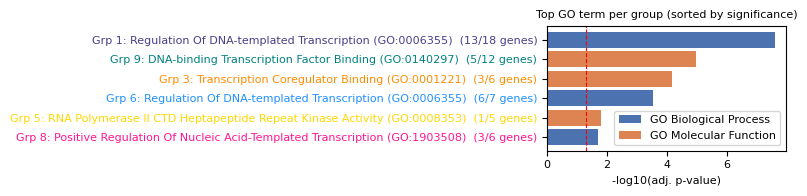

 group                                                                     term hits  group_size         adjP                    library
     1                   Regulation Of DNA-templated Transcription (GO:0006355)   13          18 2.631222e-08 GO_Biological_Process_2023
     9                    DNA-binding Transcription Factor Binding (GO:0140297)    5          12 1.060727e-05 GO_Molecular_Function_2023
     3                           Transcription Coregulator Binding (GO:0001221)    3           6 6.982739e-05 GO_Molecular_Function_2023
     6                   Regulation Of DNA-templated Transcription (GO:0006355)    6           7 3.065117e-04 GO_Biological_Process_2023
     5   RNA Polymerase II CTD Heptapeptide Repeat Kinase Activity (GO:0008353)    1           5 1.652331e-02 GO_Molecular_Function_2023
     8 Positive Regulation Of Nucleic Acid-Templated Transcription (GO:1903508)    3           6 1.978607e-02 GO_Biological_Process_2023


: 

In [ ]:
# GO enrichment analysis per group — one top term per group in a single figure
import gseapy as gp
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch



GO_LIBS     = ["GO_Biological_Process_2023", "GO_Molecular_Function_2023"]
PVAL_CUTOFF = 0.05

top_terms = []

for grp in sorted(grouped.index):
    genes = [g for g in grouped.loc[grp] if isinstance(g, str)]
    if len(genes) < 3:
        continue
    group_dfs = []
    for lib in GO_LIBS:
        try:
            enr = gp.enrichr(gene_list=genes, gene_sets=lib, organism="human",
                             outdir=None, verbose=False)
            df = enr.results.copy()
            df["library"] = lib
            group_dfs.append(df)
        except Exception as e:
            print(f"Group {grp} / {lib}: {e}")
    if not group_dfs:
        continue
    combined = pd.concat(group_dfs, ignore_index=True)
    combined = combined[combined["Adjusted P-value"] < PVAL_CUTOFF]
    if combined.empty:
        print(f"Group {grp}: no significant terms")
        continue
    best = combined.nsmallest(1, "Adjusted P-value").iloc[0]
    # Overlap column is hits/pathway_size — extract hits in group
    overlap_str = best.get("Overlap", "?/?")
    hits = overlap_str.split("/")[0] if "/" in str(overlap_str) else "?"
    top_terms.append({
        "group":      grp,
        "term":       best["Term"],
        "adjP":       best["Adjusted P-value"],
        "-log10P":    -math.log10(max(best["Adjusted P-value"], 1e-300)),
        "library":    best["library"],
        "hits":       hits,
        "group_size": len(genes),
    })

if not top_terms:
    print("No significant GO terms found.")
else:
    # Sort by significance
    summary = pd.DataFrame(top_terms).sort_values("-log10P", ascending=False)
    colors = ["#4C72B0" if "Biological" in lib else "#DD8452"
              for lib in summary["library"]]
    labels = [
        f"Grp {row.group}: {row.term}  ({row.hits}/{row.group_size} genes)"
        for row in summary.itertuples()
    ]

    fig, ax = plt.subplots(figsize=(8, max(2, len(summary) * 0.3)))
    ax.barh(labels, summary["-log10P"], color=colors)
    ax.invert_yaxis()
    ax.axvline(x=-math.log10(PVAL_CUTOFF), color="red", linestyle="--", linewidth=0.8,
               label=f"p={PVAL_CUTOFF}")
    ax.set_xlabel("-log10(adj. p-value)", fontsize=8)
    ax.set_title("Top GO term per group (sorted by significance)", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    fig.canvas.draw()
    for lbl in ax.get_yticklabels():
        txt = lbl.get_text()
        try:
            grp_num = int(txt.split(":")[0].replace("Grp", "").strip())
            lbl.set_color(new_colormap[(grp_num - 1) % len(new_colormap)])
        except (ValueError, IndexError):
            pass
    legend_elements = [Patch(facecolor="#4C72B0", label="GO Biological Process"),
                       Patch(facecolor="#DD8452", label="GO Molecular Function")]
    ax.legend(handles=legend_elements, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{figure_dir}/go_top_term_per_group.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{figure_dir}/go_top_term_per_group.pdf", bbox_inches="tight")
    plt.savefig(f"{figure_dir}/go_top_term_per_group.svg", bbox_inches="tight")
    plt.show()
    print(summary[["group", "term", "hits", "group_size", "adjP", "library"]].to_string(index=False))
